In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/cs-4210-sp-26-competition-about-facial-expression/train_target.csv
/kaggle/input/competitions/cs-4210-sp-26-competition-about-facial-expression/sample-submission.csv
/kaggle/input/competitions/cs-4210-sp-26-competition-about-facial-expression/train_data.csv
/kaggle/input/competitions/cs-4210-sp-26-competition-about-facial-expression/test_data.csv


In [32]:
import torch
from PIL import Image
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.optim import lr_scheduler

from torchvision import models

In [33]:
# Check if cuda exists and if not, use cpu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [34]:
# load the training, testing, target data
train_path = "/kaggle/input/competitions/cs-4210-sp-26-competition-about-facial-expression/train_data.csv"
test_path = "/kaggle/input/competitions/cs-4210-sp-26-competition-about-facial-expression/test_data.csv"


trainTar_path = "/kaggle/input/competitions/cs-4210-sp-26-competition-about-facial-expression/train_target.csv"

train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

tar_df = pd.read_csv(trainTar_path, header=None)
labels = tar_df[0].values

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train Target shape: {tar_df.shape}")

print(train_df.columns)
print(train_df.head())
print(test_df.head())
print(tar_df.head())
print(labels)


Train shape: (16175, 2304)
Test shape: (3965, 2304)
Train Target shape: (16175, 1)
Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2294, 2295, 2296, 2297, 2298, 2299, 2300, 2301, 2302, 2303],
      dtype='int64', length=2304)
   0     1     2     3     4     5     6     7     8     9     ...  2294  \
0   146   146   145   145   145   142   140   114   126   128  ...   103   
1     9    12    34    72    98   110   113   116   126   134  ...   141   
2   255   129    62    59    45    31    29    26    32    23  ...   122   
3   217   191   222   176   150   201   157    72    59    74  ...   223   
4    19    11     4    37    62    78    98   113   121   126  ...   152   

   2295  2296  2297  2298  2299  2300  2301  2302  2303  
0   103    93    87    73    65    65    76    85    81  
1   121   131   118    93    74    31     7     4     9  
2   130   138   113    43    26    16    12    14    16  
3   229   114    70   111    95    71   109   15

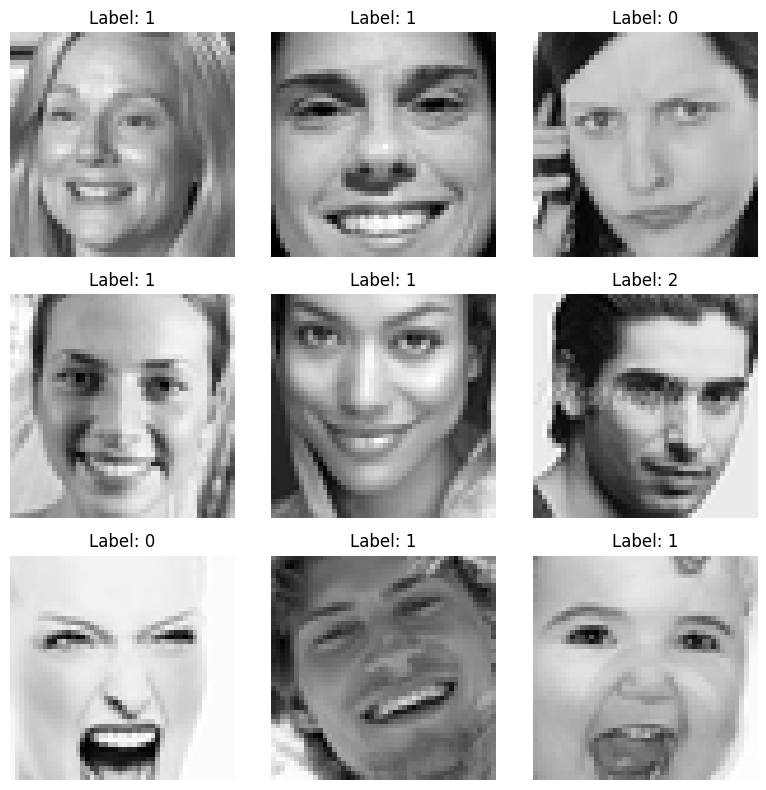

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

# Iterate through the first 9 images and their corresponding axes
for i, ax in enumerate(axes.flat):
    image = train_df.iloc[i].values.reshape(48, 48)
    label = tar_df.iloc[i, 0]
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [36]:
# Check for class imbalance
print(tar_df[0].value_counts().sort_index()) # Checking labels counts

0
0    3995
1    7215
2    4965
Name: count, dtype: int64


In [37]:
# Split the train and val data into 80-20

X_train, X_val, y_train, y_val = train_test_split(
    train_df,
    tar_df,
    test_size = 0.2,
    random_state=42,
    stratify=labels   
)

In [38]:
# Check train and val data size to ensure correct splitting

print(len(X_train) / len(train_df))
print(len(X_val) / len(train_df))

0.8
0.2


In [39]:
# Data transforms with augmentation for training
# to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Simple transforms
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [40]:
# defining the dataset

class FERDataset(Dataset):
    def __init__(self, data_df, target_df=None, transform=None):
        self.data_df = data_df
        self.target_df = target_df
        self.transform = transform

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        # Extract pixel values, ensure they are 8-bit integers, and reshape to 2D
        image = self.data_df.iloc[idx].values.astype(np.uint8).reshape(48, 48)
        # Convert NumPy array to PIL Image for torchvision transforms
        image = Image.fromarray(image)

        # Apply augmentations/normalization
        if self.transform:
            image = self.transform(image)

        # Return image and label for training/val
        if self.target_df is not None:
            label = int(self.target_df.iloc[idx, 0])
            return image, label
        else:
            return image
        
        

In [41]:
# the Training Dataset uses data augmentation (train_transform) to improve model generalization
train_dataset = FERDataset(X_train, y_train, transform=train_transform)
val_dataset = FERDataset(X_val, y_val, transform=val_transform)
test_dataset = FERDataset(test_df, None, transform=val_transform)

In [42]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [43]:
# Extract the first batch of data from the training iterator
images, labels = next(iter(train_loader))
# Verify batch dimensions: [Batch, Channels, Height, Width]
print(images.shape)   
print(labels.shape)  
print(images.min(), images.max())

torch.Size([64, 3, 224, 224])
torch.Size([64])
tensor(-2.1179) tensor(2.6400)


In [46]:
# Load pre-trained ResNet-18 with the latest optimized ImageNet weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Replace final fully connected layer to output 3 emotion classes
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)


images, labels = next(iter(train_loader))
images = images.to(device)
# Pass the batch through the model to get raw prediction scores
outputs = model(images)

print(outputs.shape)

torch.Size([64, 3])


In [48]:
# Define loss function with label smoothing to prevent overfitting on ambiguous expressions
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Set up a learning rate scheduler that halves the LR when validation accuracy plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

In [49]:
# Initialize training hyperparameters
num_epochs = 100
best_val_acc = 0.0
best_epoch = 0
patience = 15
patience_counter = 0

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):

    # train the model in 50 epochs, however, it may stop when validation
    # can no longer improve
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # Reset gradients from the previous batch

        outputs = model(images)
        loss = criterion(outputs, labels) # Calculate loss

        loss.backward() # Compute gradients via backpropagation
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    
    # Calculate average training metrics for each epoc
    epoch_train_loss = running_train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # ------Validating the model-----
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = running_val_loss / val_total
    epoch_val_acc = val_correct / val_total

    # Store losses for validation
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    scheduler.step(epoch_val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}")

    # Save the model if validation accuracy improves
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        patience_counter = 0

        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print("Best model saved!")
    else:
        patience_counter += 1

    # Early stopping to avoid overfitting
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

print(f"Best Val Acc: {best_val_acc:.4f} at epoch {best_epoch}")

Epoch 1/100
Train Loss: 0.7504 | Train Acc: 0.7276
Val   Loss: 0.6595 | Val   Acc: 0.7827
Best model saved!
Epoch 2/100
Train Loss: 0.6567 | Train Acc: 0.7916
Val   Loss: 0.6437 | Val   Acc: 0.7913
Best model saved!
Epoch 3/100
Train Loss: 0.6345 | Train Acc: 0.8072
Val   Loss: 0.6463 | Val   Acc: 0.7845
Epoch 4/100
Train Loss: 0.6218 | Train Acc: 0.8128
Val   Loss: 0.6546 | Val   Acc: 0.7935
Best model saved!
Epoch 5/100
Train Loss: 0.5971 | Train Acc: 0.8304
Val   Loss: 0.6344 | Val   Acc: 0.7981
Best model saved!
Epoch 6/100
Train Loss: 0.5915 | Train Acc: 0.8317
Val   Loss: 0.6185 | Val   Acc: 0.8148
Best model saved!
Epoch 7/100
Train Loss: 0.5830 | Train Acc: 0.8371
Val   Loss: 0.6413 | Val   Acc: 0.8158
Best model saved!
Epoch 8/100
Train Loss: 0.5676 | Train Acc: 0.8478
Val   Loss: 0.6253 | Val   Acc: 0.8074
Epoch 9/100
Train Loss: 0.5636 | Train Acc: 0.8495
Val   Loss: 0.6257 | Val   Acc: 0.8164
Best model saved!
Epoch 10/100
Train Loss: 0.5538 | Train Acc: 0.8564
Val   Loss: 

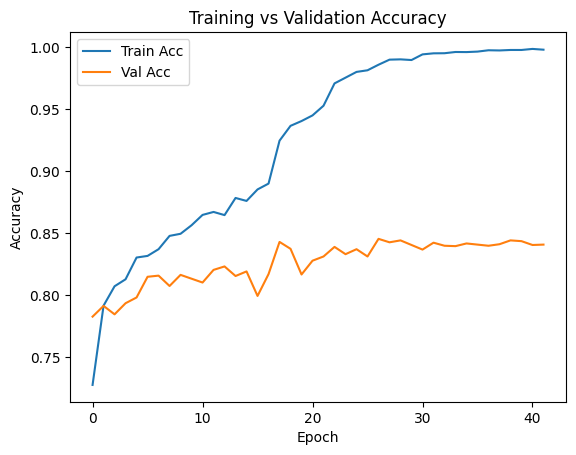

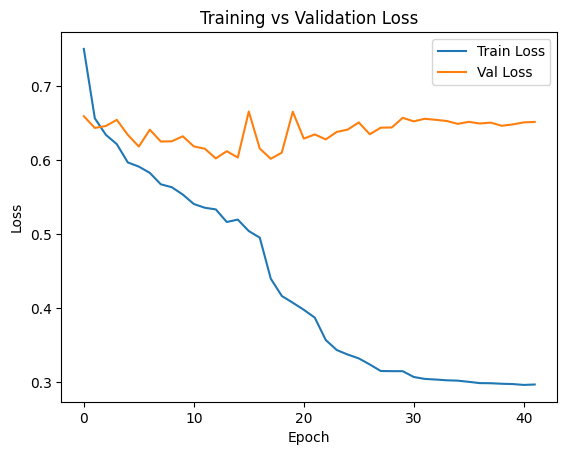

In [50]:
# Plot training and validation accuracy over epochs to check for convergence
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()
# Plot training and validation loss to identify potential overfitting or underfitting
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

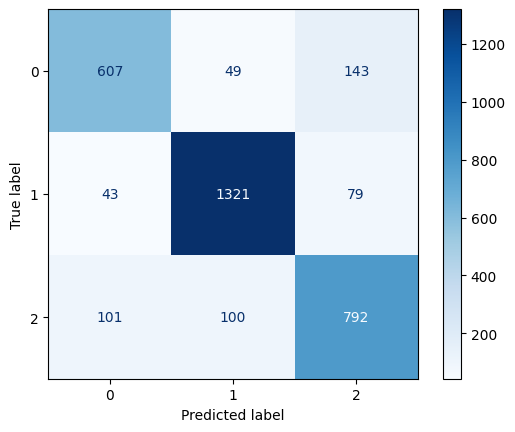

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
# Confusion matrix comparing truth to predictions
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(cmap="Blues")
plt.show()

In [52]:
# Load the saved weights from the best-performing epoch
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
# Set model to evaluation mode for consistent, deterministic inference
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [53]:
# Initialize an empty list to store predicted emotion classes
predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        predictions.extend(preds.cpu().numpy())

In [54]:
# Load the competition's sample submission file to use as a template
sample = pd.read_csv("/kaggle/input/competitions/cs-4210-sp-26-competition-about-facial-expression/sample-submission.csv")
print(sample.head())
print(sample.columns)

   Id  Category
0   0         1
1   1         1
2   2         0
3   3         2
4   4         0
Index(['Id', 'Category'], dtype='object')


In [55]:
# Create a DataFrame mapping each prediction to its corresponding row index
submission = pd.DataFrame({
    "Id": range(len(predictions)),
    "Category": predictions
})

submission.to_csv("/kaggle/working/submission.csv", index=False)